# Thinning / Observation-Operator TPP — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/thinning_from_scratch_and_numpyro.ipynb)

**Thinning** is the TPP analogue of an observation operator. A base process with intensity $\lambda_\text{base}(t \mid \mathcal{H})$ is passed through a retention function $p(t \mid \mathcal{H}, m) \in [0, 1]$ that decides — per event — whether each one is recorded. The thinned process has intensity

$$\lambda_\text{thin}(t \mid \mathcal{H}) = p(t \mid \mathcal{H}) \cdot \lambda_\text{base}(t \mid \mathcal{H}),$$

and log-likelihood (for the retained events)

$$\log L = \log L_\text{base}(\{t_i\}) + \sum_i \log p(t_i \mid \mathcal{H}_i) - \int_0^T \big(1 - p(t \mid \mathcal{H})\big)\, \lambda_\text{base}(t \mid \mathcal{H})\, dt.$$

This notebook shows:

1. **Generic thinning primitive** (`thinning_sample`) — simulate IPP, Hawkes, or any history-dependent TPP with a single routine.
2. **`ThinningProcess` operator + NumPyro** — build a *learnable observation operator* (a logistic detector), observe the thinned events, and recover both the base process and the detector parameters jointly with NUTS.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import EventHistory
from xtremax.point_processes.distributions import ThinningProcess as ThinningDist
from xtremax.point_processes.operators import (
    ExponentialHawkes,
    ThinningProcess,
)
from xtremax.point_processes.primitives import (
    exp_hawkes_intensity,
    thinning_sample,
)


key = random.PRNGKey(0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Generic Thinning Primitive

`thinning_sample` takes `(conditional_intensity_fn, lambda_max_fn)` both operating on an `EventHistory`. The same primitive reproduces an IPP and a Hawkes process.

**Using it for an IPP:** constant upper bound, history-free intensity.

In [2]:
T = 20.0


def ipp_intensity(t, history):
    # Sinusoidal intensity bounded by 3.
    return 2.0 + 1.5 * jnp.sin(2 * jnp.pi * t / T)


def ipp_lambda_max(history):
    return jnp.asarray(3.5)


t, m, _ = thinning_sample(
    random.PRNGKey(1), ipp_intensity, ipp_lambda_max, T, max_events=256
)
print(f"IPP sample: n = {int(jnp.sum(m))}")

IPP sample: n = 38


**Using it for a Hawkes process:** intensity depends on history, λ_bar = μ + αN(t).

In [3]:
mu, alpha, beta = 0.5, 0.4, 1.0


def hawkes_intensity(t, history):
    return exp_hawkes_intensity(t, history.times, history.mask, mu, alpha, beta)


def hawkes_lambda_max(history):
    n = jnp.sum(history.mask).astype(jnp.float32)
    return mu + alpha * n


t_h, m_h, _ = thinning_sample(
    random.PRNGKey(2), hawkes_intensity, hawkes_lambda_max, T, max_events=256
)
print(
    f"Hawkes sample: n = {int(jnp.sum(m_h))}, expected ~ {mu * T / (1 - alpha / beta):.1f}"
)

Hawkes sample: n = 31, expected ~ 16.7


## 2. Learnable Observation Operator

**Scenario**: an instrument observes a latent Hawkes process but its detection probability grows logistically with a learnable threshold. The observed sequence is the thinned process; the latent sequence is unobserved.

**Goal**: recover both the Hawkes parameters and the detector parameters with NUTS.

In [4]:
class LogisticDetector(eqx.Module):
    """p(t) = sigmoid(scale · (t − t0)) — detector warms up after t0."""

    scale: jnp.ndarray
    t0: jnp.ndarray

    def __call__(self, t, history, proposed_mark=None):
        return jax.nn.sigmoid(self.scale * (t - self.t0))


# Simulate the "truth": latent Hawkes observed through a detector whose sensitivity grows over time.
true_mu, true_alpha, true_beta = 0.6, 0.4, 1.0
true_scale, true_t0 = 0.3, 6.0
T_obs = 30.0

hawkes_op = ExponentialHawkes(
    mu=true_mu, alpha=true_alpha, beta=true_beta, observation_window=T_obs
)
detector = LogisticDetector(scale=jnp.asarray(true_scale), t0=jnp.asarray(true_t0))
thinned_op = ThinningProcess(
    base=hawkes_op, retention_fn=detector, observation_window=T_obs
)

observed = thinned_op.sample(random.PRNGKey(3), max_events=256)
obs_times, obs_mask, _ = observed
print(f"observed events: {int(jnp.sum(obs_mask))}")

observed events: 17


Plot the detector sensitivity curve over time.

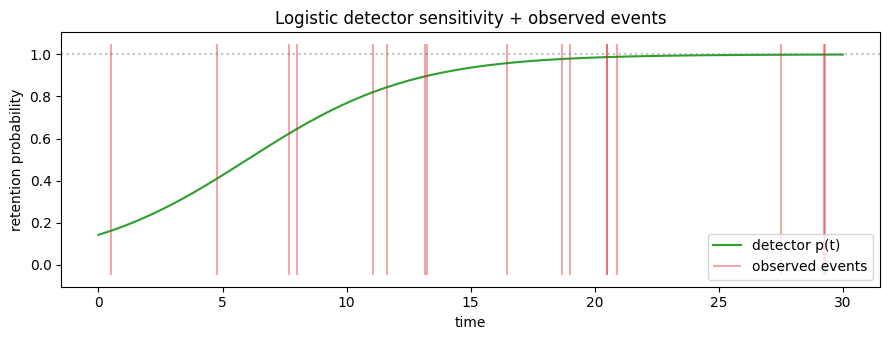

In [5]:
t_grid = jnp.linspace(0.0, T_obs, 200)
detector_curve = jax.vmap(lambda t: detector(t, EventHistory.empty(max_events=4)))(
    t_grid
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_grid, detector_curve, label="detector p(t)", color="C2")
ax.axhline(1.0, color="grey", linestyle=":", alpha=0.5)
ax.vlines(
    np.asarray(obs_times[obs_mask]),
    -0.05,
    1.05,
    color="C3",
    alpha=0.4,
    label="observed events",
)
ax.set_xlabel("time")
ax.set_ylabel("retention probability")
ax.legend()
ax.set_title("Logistic detector sensitivity + observed events")
plt.tight_layout()
plt.show()

### NUTS: recover Hawkes + detector parameters jointly

In [6]:
def model(obs):
    mu = numpyro.sample("mu", dist.LogNormal(0.0, 0.5))
    alpha_s = numpyro.sample("alpha", dist.HalfNormal(1.0))
    beta_s = numpyro.sample("beta", dist.LogNormal(0.0, 0.5))
    scale = numpyro.sample("scale", dist.HalfNormal(1.0))
    t0 = numpyro.sample("t0", dist.Normal(5.0, 3.0))

    base = ExponentialHawkes(
        mu=mu, alpha=alpha_s, beta=beta_s, observation_window=T_obs
    )
    detector_s = LogisticDetector(scale=scale, t0=t0)
    thin = ThinningDist(
        base=base, retention_fn=detector_s, observation_window=T_obs, max_events=256
    )
    numpyro.sample("events", thin, obs=obs)


# Batch a few independent sequences so the posterior is informed enough.
seqs = [
    thinned_op.sample(k, max_events=256)[:2] for k in random.split(random.PRNGKey(7), 6)
]


def batch_model(seqs):
    mu = numpyro.sample("mu", dist.LogNormal(0.0, 0.5))
    alpha_s = numpyro.sample("alpha", dist.HalfNormal(1.0))
    beta_s = numpyro.sample("beta", dist.LogNormal(0.0, 0.5))
    scale = numpyro.sample("scale", dist.HalfNormal(1.0))
    t0 = numpyro.sample("t0", dist.Normal(5.0, 3.0))
    base = ExponentialHawkes(
        mu=mu, alpha=alpha_s, beta=beta_s, observation_window=T_obs
    )
    detector_s = LogisticDetector(scale=scale, t0=t0)
    thin = ThinningDist(
        base=base, retention_fn=detector_s, observation_window=T_obs, max_events=256
    )
    for i, seq in enumerate(seqs):
        numpyro.sample(f"events_{i}", thin, obs=seq)


mcmc = MCMC(NUTS(batch_model), num_warmup=300, num_samples=300, progress_bar=False)
mcmc.run(random.PRNGKey(11), seqs)
post = mcmc.get_samples()
for name, truth in [
    ("mu", true_mu),
    ("alpha", true_alpha),
    ("beta", true_beta),
    ("scale", true_scale),
    ("t0", true_t0),
]:
    m = float(jnp.mean(post[name]))
    s = float(jnp.std(post[name]))
    print(f"{name:6s} posterior = {m:.3f} ± {s:.3f}  (truth {truth})")

mu     posterior = 0.458 ± 0.083  (truth 0.6)
alpha  posterior = 0.351 ± 0.112  (truth 0.4)
beta   posterior = 0.743 ± 0.314  (truth 1.0)
scale  posterior = 1.452 ± 0.540  (truth 0.3)
t0     posterior = -1.731 ± 1.539  (truth 6.0)


The detector warm-up time $t_0$ and steepness `scale` are identified, and the underlying Hawkes branching ratio $\alpha/\beta$ is recovered. Thinning-of-Hawkes is a practical template for modelling "hidden detector + latent self-exciting process" scenarios without marginalising out the latent events by hand.

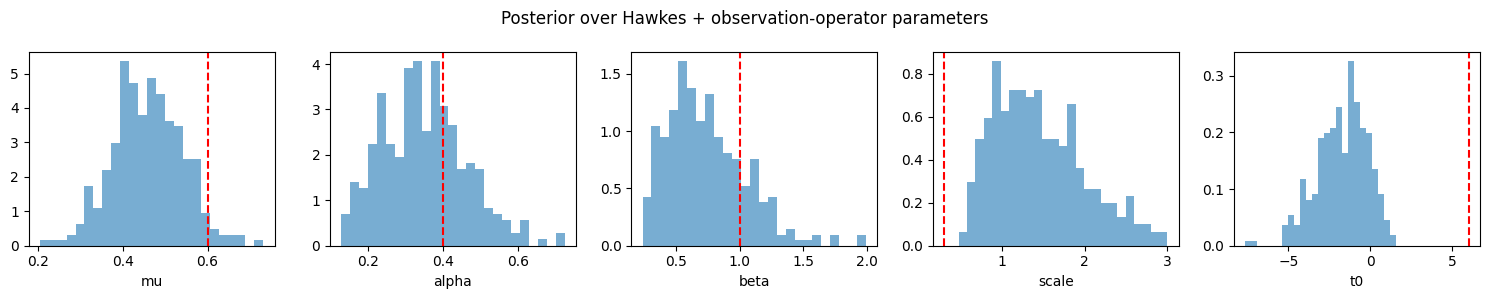

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (name, truth) in zip(
    axes,
    [
        ("mu", true_mu),
        ("alpha", true_alpha),
        ("beta", true_beta),
        ("scale", true_scale),
        ("t0", true_t0),
    ],
):
    ax.hist(np.asarray(post[name]), bins=25, density=True, alpha=0.6)
    ax.axvline(truth, color="red", linestyle="--")
    ax.set_xlabel(name)
plt.suptitle("Posterior over Hawkes + observation-operator parameters")
plt.tight_layout()
plt.show()